In [1]:
import matplotlib.pyplot as plt
import numpy as np
import  scipy.stats
from sklearn.mixture import GaussianMixture

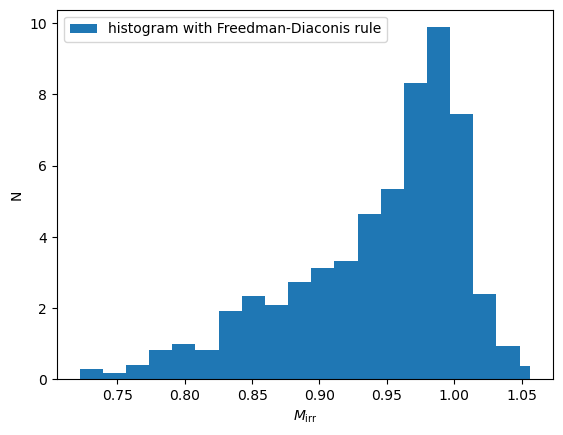

In [2]:
# the irreducible mass of a BH
from astroML import stats as astroMLstats

N=1000

X=np.random.uniform(0,1,N)
M = scipy.stats.norm(loc=1,scale=0.02)
M_samp=M.rvs(N)

M_irr= M_samp*((1+(1-X**2)**(1/2))/2)**(1/2)

sigmaG2 = astroMLstats.sigmaG(M_irr)
binsize = 2.7*sigmaG2/(N**(1/3))
binsG = np.append(np.arange(start=M_irr.min(), stop=M_irr.max(), step=binsize) , M_irr.max()) #Complete
plt.hist(M_irr, bins=binsG, density=True, label='histogram with Freedman-Diaconis rule')
plt.legend()
plt.xlabel(r'$M_{\mathrm{irr}}$')
plt.ylabel('N');

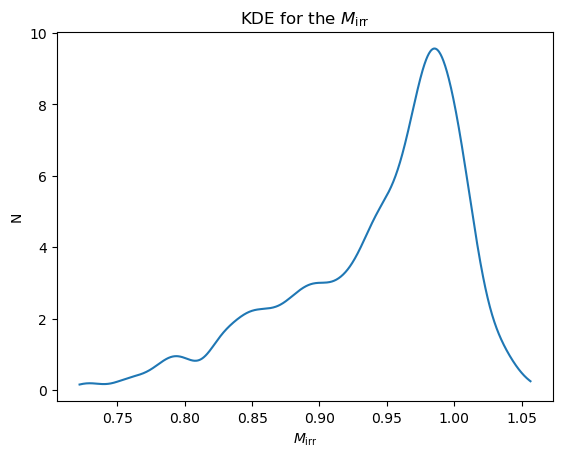

In [3]:
from sklearn.neighbors import KernelDensity

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

xgrid = np.linspace(M_irr.min(),M_irr.max(),1000)
M_irrPDF = kde_sklearn(M_irr,bandwidth=0.01,kernel="gaussian")
plt.plot(xgrid,M_irrPDF)
plt.xlabel(r'$M_{\mathrm{irr}}$')
plt.ylabel('N')
plt.title('KDE for the' + ' ' +r'$M_{\mathrm{irr}}$');


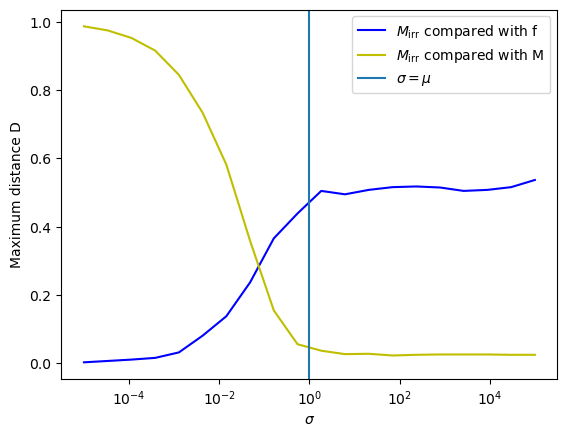

In [4]:
#do f

f= ((1+(1-X**2)**(1/2))/2)**(1/2)

#now lets copute the KS distance
ks_MF=[]
ks_MM=[]
sigma= np.logspace(-5,5,20) #for a huge range of sigma

for i in sigma:
    M = scipy.stats.norm(loc=1,scale=i)
    M_samp=M.rvs(N)
    M_irr= M_samp*((1+(1-X**2)**(1/2))/2)**(1/2)
    ks_MF.append(scipy.stats.ks_2samp(M_irr/1, f))
    ks_MM.append(scipy.stats.ks_2samp(M_irr, M_samp))

ks_MF= np.array(ks_MF)
ks_MM= np.array(ks_MM)

plt.plot(sigma, ks_MF[:,0], color='b', label=r'$M_{\mathrm{irr}}$ compared with f')
plt.plot(sigma, ks_MM[:,0], color='y', label=r'$M_{\mathrm{irr}}$ compared with M')
plt.axvline(1, label = r'$\sigma = \mu$')
plt.xlabel(r'$\sigma$')
plt.ylabel('Maximum distance D')
plt.semilogx()
plt.legend();

In [5]:
print('For small σ, M₍ᵢᵣᵣ₎ goes as f')
print('For small σ, M₍ᵢᵣᵣ₎ goes as M')

For small σ, M₍ᵢᵣᵣ₎ goes as f
For small σ, M₍ᵢᵣᵣ₎ goes as M


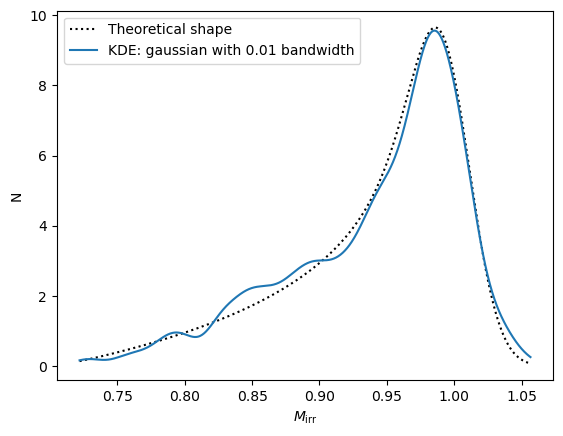

In [6]:
from scipy.integrate import quad

N=1000

sigma=0.02

def integrand(f,M_irr):
    return ((2/np.pi)**0.5/sigma)*np.exp(-(M_irr/f -1)**2/(2*sigma**2))*(2*f**2-1)/(f*(1-f**2)**0.5)

p_Mirr = [quad(lambda f: integrand(f,M_irr_i), 1/2**0.5,1)[0] for M_irr_i in xgrid]

plt.plot(xgrid,p_Mirr,label='Theoretical shape',c='black',ls='dotted')
plt.plot(xgrid,M_irrPDF, label='KDE: gaussian with 0.01 bandwidth' )
plt.legend()
plt.xlabel(r'$M_{\mathrm{irr}}$')
plt.ylabel('N');


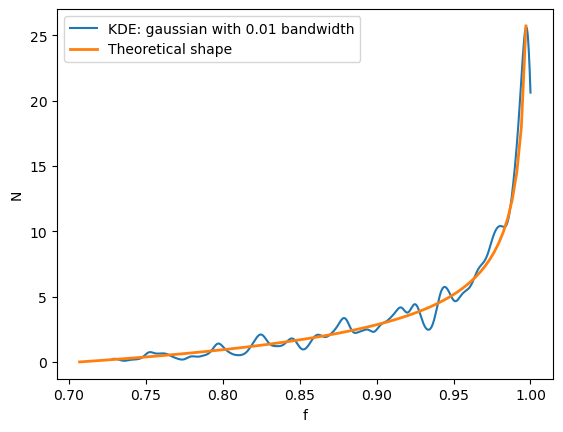

In [8]:
#pdf recostruction of f 

N=1000

X=np.random.uniform(0,1,N)
f= ((1+(1-X**2)**(1/2))/2)**(1/2)

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(fgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

fgrid = np.linspace(f.min(),f.max(),1000)
fPDF = kde_sklearn(f,bandwidth=0.003,kernel="gaussian")
plt.plot(fgrid,fPDF, label='KDE: gaussian with 0.01 bandwidth')
f_2 = np.linspace(1/2**0.5,1,100)[:-1]
pdff = 2*(2*f_2**2-1)/(1 - f_2**2)**0.5
plt.plot(f_2,pdff,lw=2, label='Theoretical shape');
plt.legend()
plt.xlabel('f')
plt.ylabel('N');
